# Cell Tracking Analysis
This notebook demonstrates the cell tracking analysis process using our custom modules.

In [35]:
%pip install opencv-python
%pip install numpy
%pip install tifffile
%pip install matplotlib
%pip install seaborn
%pip install pandas
%pip install Pillow
%pip install tqdm
%pip install ipywidgets
%pip install jupyter


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: pip3 install --upgrade pi

In [45]:
import sys
from pathlib import Path
import time
from datetime import datetime
import os
from IPython.display import Image, display

# Add Source directory to Python path
source_dir = Path('sourcecode')
sys.path.append(str(source_dir.absolute()))

# Import our custom modules
from blob_tracker import BlobTracker
from metrics_calculator import CellTrackingMetrics
from image_processor import ImageProcessor
from utils import setup_logging, get_input_file

## Setup Output Directories

In [37]:
# Setup paths
data_dir = Path('.')
output_folder = data_dir/'data' / 'Outputs'
log_folder = output_folder / 'logs'

# Create output directories
output_folder.mkdir(exist_ok=True, parents=True)
log_folder.mkdir(exist_ok=True)



## Get Input File

In [38]:
print(f"Current working directory: {os.getcwd()}")

# Get input file
input_path = get_input_file()
print(f"Selected input file: {input_path}")

Current working directory: /Users/blackvision/Desktop/wbmcimg
Randomly selected file from directory: Data/Input/AR1_K_mA.tif
Selected input file: Data/Input/AR1_K_mA.tif


## Initialize Processing Classes

In [39]:
# Create instances of our classes
tracker = BlobTracker()
metrics_calculator = CellTrackingMetrics()
image_processor = ImageProcessor(logger)

# Create output paths
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_name = input_path.stem
output_dir = output_folder / output_name
output_dir.mkdir(exist_ok=True)
output_path = output_dir / f"tracked_cells_{timestamp}.tiff"
plots_dir = output_dir / 'movement_plots'
plots_dir.mkdir(exist_ok=True)

## Process TIFF Stack

2025-01-09 21:37:27,460 - INFO - Starting cell tracking analysis
2025-01-09 21:37:27,461 - INFO - Input file: Data/Input/AR1_K_mA.tif
2025-01-09 21:37:27,462 - INFO - Output directory: data/Outputs/AR1_K_mA_1
2025-01-09 21:37:27,485 - INFO - Total frames in TIFF: 8765


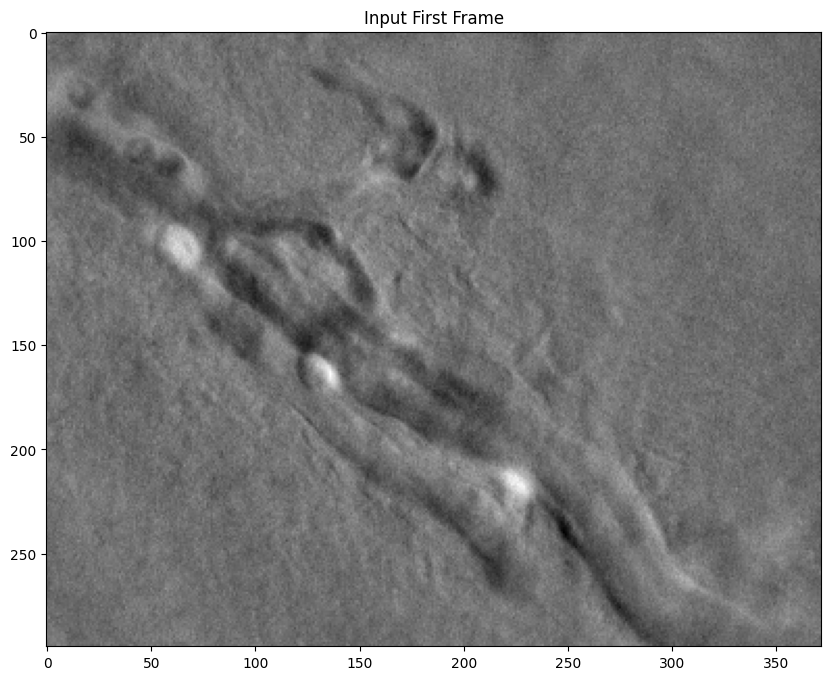

Processing frames:   0%|          | 0/8765 [00:00<?, ?it/s]

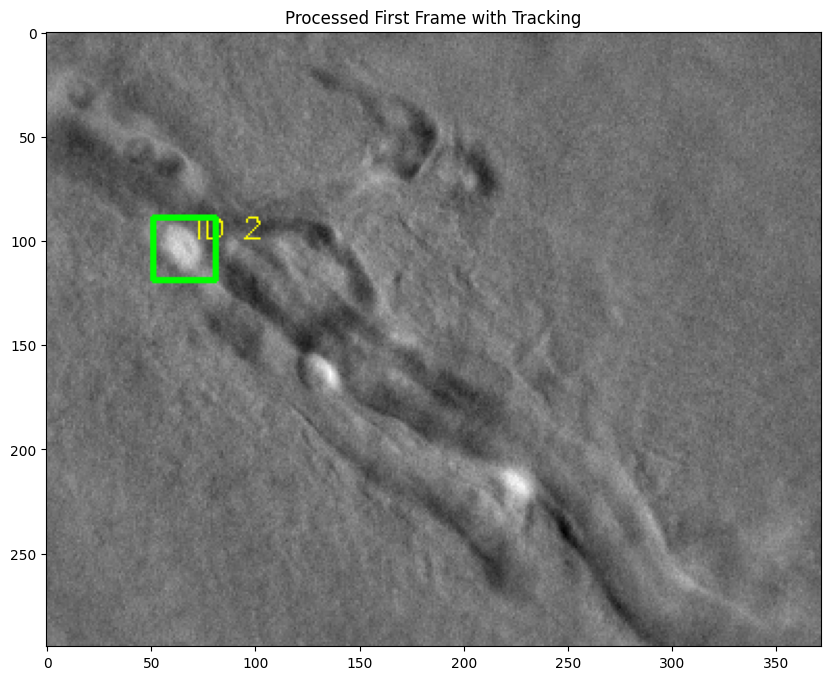

Processing frames: 100%|██████████| 8765/8765 [00:05<00:00, 1624.15it/s]
2025-01-09 21:37:33,157 - INFO - Saving processed frames...


In [40]:
start_time = time.time()

logger.info("Starting cell tracking analysis")


def get_unique_output_dir(base_path, folder_name):
    """
    Creates a unique output directory by appending numbers if the directory already exists.
    
    Args:
        base_path (Path): Base directory path
        folder_name (str): Desired folder name
    
    Returns:
        Path: Unique directory path
    """
    output_dir = base_path / folder_name
    if not output_dir.exists():
        return output_dir
    
    counter = 1
    while True:
        new_dir = base_path / f"{folder_name}_{counter}"
        if not new_dir.exists():
            return new_dir
        counter += 1


output_name = input_path.stem
output_dir = get_unique_output_dir(output_folder, output_name)
output_dir.mkdir(parents=True)
logger.info(f"Input file: {input_path}")
logger.info(f"Output directory: {output_dir}")

def log_processed_file(input_file, output_dir, log_folder):
    """
    Logs information about processed files to a master log file.
    
    Args:
        input_file (Path): Path to the input file that was processed
        output_dir (Path): Path to the output directory
        log_folder (Path): Path to the logs directory
    """
    master_log_file = log_folder / "processed_files_history.log"
    timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    
    log_entry = f"[{timestamp}] Processed file: {input_file.absolute()} | Output directory: {output_dir.absolute()}\n"
    
    # Append the log entry to the master log file
    with open(master_log_file, 'a') as f:
        f.write(log_entry)





# Process TIFF stack
num_frames = image_processor.process_tiff_stack(input_path, output_path, tracker, metrics_calculator)
# Log the processed file
log_processed_file(input_path, output_dir, log_folder)

## Calculate and Display Metrics

In [42]:
# Calculate and display metrics for Cell ID 2
logger.info("Calculating and plotting metrics for Cell ID 2...")

if 2 in tracker.get_tracks():
    positions = tracker.get_tracks()[2]
    metrics = metrics_calculator.calculate_metrics(positions, num_frames)

    if metrics:
        print("\n=== Metrics for Cell ID 2 ===")
        print(f"Total Distance: {metrics['total_distance']:.2f} pixels")
        print(f"Net Displacement: {metrics['displacement']:.2f} pixels")
        print(f"Average Velocity: {metrics['avg_velocity']:.2f} pixels/frame")
        print(f"Maximum Velocity: {metrics['max_velocity']:.2f} pixels/frame")
        print(f"Average Acceleration: {metrics['avg_acceleration']:.2f} pixels/frame²")
        print(f"Direction Changes: {metrics['directional_changes']}")
        print(f"Confinement Ratio: {metrics['confinement_ratio']:.3f}")

        # Generate and display plots
        metrics_calculator.plot_movement_graphs(2, metrics, plots_dir)
        # Display the generated plots
        print(f"\nMovement Analysis Plots:")
        for plot_file in plots_dir.glob('*.png'):
            print(f"\n{plot_file.name}:")
            display(Image(filename=str(plot_file)))
else:
    logger.warning("Cell ID 2 not found in the tracked cells.")

end_time = time.time()
logger.info(f"Processing completed in {end_time - start_time:.2f} seconds.")

2025-01-09 21:42:50,547 - INFO - Calculating and plotting metrics for Cell ID 2...



=== Metrics for Cell ID 2 ===
Total Distance: 237.13 pixels
Net Displacement: 64.38 pixels
Average Velocity: 0.63 pixels/frame
Maximum Velocity: 2.83 pixels/frame
Average Acceleration: -0.00 pixels/frame²
Direction Changes: 233
Confinement Ratio: 0.272

Movement Analysis Plots:

cell_2_movement_analysis.png:


NameError: name 'Image' is not defined